<a href="https://colab.research.google.com/github/SinCosTanTya/Lifestyle-and-Health/blob/main/Lifestyle_and_Health_Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Research question: Does a person’s sex have a statistically significant influence on the relationship between BMI and systolic blood pressure?

> Add blockquote



In [2]:
import csv
import pandas as pd
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt

In [3]:
#Importing the dataframe
url="https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/NHANES%202017-2018%20Data/nhanes_2017_2018_healthy_habits_cleaned.csv"
health_df=pd.read_csv(url)
health_df.head()

,age,gender,sleep_hours_weekday,bmi,systolic_bp,diastolic_bp,minutes_sedentary_daily,vigorous_recreational_activity,moderate_recreational_activity,walk_or_bicycle,general_health,feel_hopeless,feel_depressed,feel_anxious,diet_quality,fast_food_meals_per_week,daily_sugar_grams,daily_fiber_grams,daily_fat_grams,daily_protein_grams
0,2.0,Female,NaN,17.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,2.0,Male,NaN,15.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.97,5.9,43.24,51.58
2,66.0,Female,8.0,31.7,NaN,NaN,300.0,No,Yes,No,Good,Not at all,Several days,Several days,Good,0.0,91.55,8.4,56.98,20.01
3,18.0,Male,10.5,21.5,112.0,74.0,240.0,No,Yes,Yes,Very good,Not at all,Not at all,Not at all,Very good,3.0,14.73,7.1,137.39,94.19
4,13.0,Male,NaN,18.1,128.0,38.0,NaN,NaN,NaN,NaN,Good,NaN,NaN,NaN,NaN,1.0,84.22,10.9,89.18,59.48


In [4]:
#Gaining general info about my dataframe
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             8366 non-null   float64
 1   gender                          8366 non-null   object 
 2   sleep_hours_weekday             5783 non-null   float64
 3   bmi                             8005 non-null   float64
 4   systolic_bp                     6302 non-null   float64
 5   diastolic_bp                    6302 non-null   float64
 6   minutes_sedentary_daily         5491 non-null   float64
 7   vigorous_recreational_activity  5533 non-null   object 
 8   moderate_recreational_activity  5533 non-null   object 
 9   walk_or_bicycle                 5533 non-null   object 
 10  general_health                  5964 non-null   object 
 11  feel_hopeless                   5087 non-null   object 
 12  feel_depressed                  51

In [5]:
#Checking for duplicates
value=health_df.duplicated().sum()
print(value)

50


In [6]:
#Drop the 50 duplicates
health_df=health_df.drop_duplicates()
#Check to make sure it worked
health_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8316 entries, 0 to 8365
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             8316 non-null   float64
 1   gender                          8316 non-null   object 
 2   sleep_hours_weekday             5783 non-null   float64
 3   bmi                             7997 non-null   float64
 4   systolic_bp                     6302 non-null   float64
 5   diastolic_bp                    6302 non-null   float64
 6   minutes_sedentary_daily         5491 non-null   float64
 7   vigorous_recreational_activity  5533 non-null   object 
 8   moderate_recreational_activity  5533 non-null   object 
 9   walk_or_bicycle                 5533 non-null   object 
 10  general_health                  5964 non-null   object 
 11  feel_hopeless                   5087 non-null   object 
 12  feel_depressed                  5136 no

In [7]:
#Replace NaN with the string "None"

health_df = health_df.fillna("None")
health_df.head()

,age,gender,sleep_hours_weekday,bmi,systolic_bp,diastolic_bp,minutes_sedentary_daily,vigorous_recreational_activity,moderate_recreational_activity,walk_or_bicycle,general_health,feel_hopeless,feel_depressed,feel_anxious,diet_quality,fast_food_meals_per_week,daily_sugar_grams,daily_fiber_grams,daily_fat_grams,daily_protein_grams
0,2.0,Female,None,17.5,None,None,None,None,None,None,None,None,None,None,None,0.0,None,None,None,None
1,2.0,Male,None,15.7,None,None,None,None,None,None,None,None,None,None,None,None,76.97,5.9,43.24,51.58
2,66.0,Female,8.0,31.7,None,None,300.0,No,Yes,No,Good,Not at all,Several days,Several days,Good,0.0,91.55,8.4,56.98,20.01
3,18.0,Male,10.5,21.5,112.0,74.0,240.0,No,Yes,Yes,Very good,Not at all,Not at all,Not at all,Very good,3.0,14.73,7.1,137.39,94.19
4,13.0,Male,None,18.1,128.0,38.0,None,None,None,None,Good,None,None,None,None,1.0,84.22,10.9,89.18,59.48


In [8]:
#Convert the string "None" back to a proper NaN object

health_df = health_df.replace("None", np.nan)

/tmp/ipykernel_3265/1365726001.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  health_df = health_df.replace("None", np.nan)


In [46]:
#Column name good, data types are good, and data is in a tidy format, but many null values ESPECIALLY in bmi and systolic bp columns
new_health_df = health_df.dropna(axis=0,how='any',subset=['bmi','systolic_bp'])
#Check to make sure it worked
new_health_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6230 entries, 3 to 8365
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             6230 non-null   float64
 1   gender                          6230 non-null   object 
 2   sleep_hours_weekday             5069 non-null   float64
 3   bmi                             6230 non-null   float64
 4   systolic_bp                     6230 non-null   float64
 5   diastolic_bp                    6230 non-null   float64
 6   minutes_sedentary_daily         4803 non-null   float64
 7   vigorous_recreational_activity  4833 non-null   object 
 8   moderate_recreational_activity  4833 non-null   object 
 9   walk_or_bicycle                 4833 non-null   object 
 10  general_health                  5313 non-null   object 
 11  feel_hopeless                   4537 non-null   object 
 12  feel_depressed                  4505 no

In [10]:
#What are the means, medians, and modes of each variable
new_health_df.describe()

,age,sleep_hours_weekday,bmi,systolic_bp,diastolic_bp,minutes_sedentary_daily,fast_food_meals_per_week,daily_sugar_grams,daily_fiber_grams,daily_fat_grams,daily_protein_grams
count,2814.000000,2814.000000,2814.000000,2814.000000,2.814000e+03,2814.000000,2814.000000,2814.000000,2814.000000,2814.000000,2814.000000
mean,47.697228,7.542466,29.665778,124.551528,7.197157e+01,339.339730,2.118692,107.963156,17.141080,89.173600,82.372974
std,18.539032,1.546205,7.094991,18.054151,1.339691e+01,195.784995,2.771571,76.874236,10.895304,50.234238,43.160494
min,18.000000,2.000000,14.800000,86.000000,5.397605e-79,3.000000,0.000000,0.710000,0.100000,2.110000,2.430000
25%,31.000000,6.500000,24.800000,112.000000,6.400000e+01,180.000000,0.000000,57.435000,9.700000,55.562500,52.957500
50%,48.000000,7.500000,28.500000,122.000000,7.200000e+01,300.000000,1.000000,91.475000,14.800000,80.525000,74.505000
75%,63.000000,8.500000,33.500000,134.000000,8.000000e+01,480.000000,3.000000,139.100000,22.300000,112.345000,102.900000
max,80.000000,14.000000,74.800000,216.000000,1.200000e+02,1140.000000,21.000000,931.160000,107.800000,536.100000,440.730000


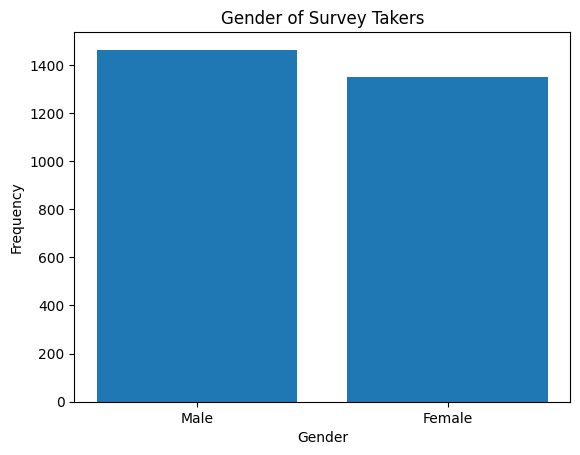

In [11]:
#I think I want to make a bar chart of amount of females that took the surverys and Males
counts=new_health_df['gender'].value_counts()
plt.bar(counts.index,counts.values)
plt.title('Gender of Survey Takers')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

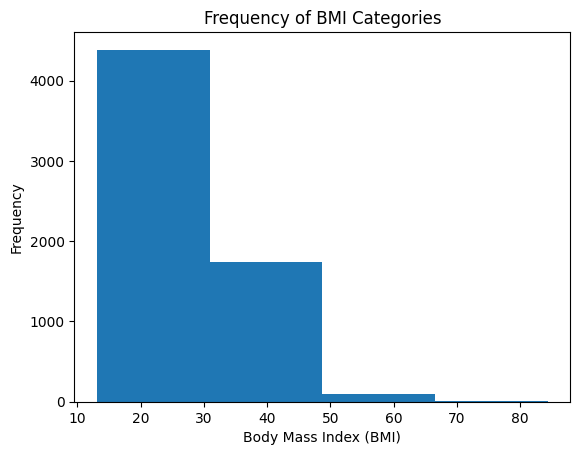

In [47]:
#Visualize data for BMI
plt.hist(new_health_df['bmi'],bins=4)

plt.title('Frequency of BMI Categories')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Frequency')

plt.show()
#question, when putting the BMI into bins, how do I do that

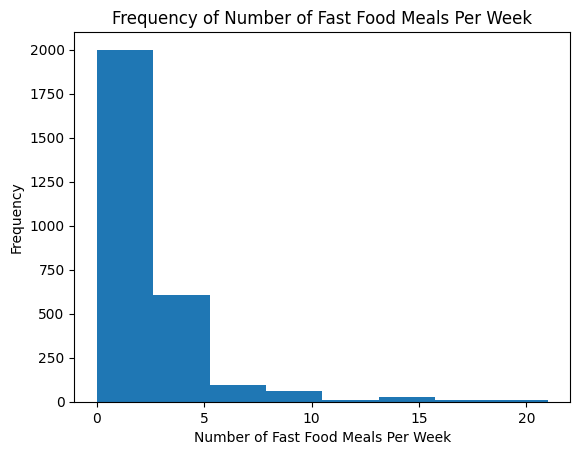

In [32]:
#Visualize data for fast food meals per week
plt.hist(new_health_df['fast_food_meals_per_week'],bins=8)

plt.title('Frequency of Number of Fast Food Meals Per Week')
plt.xlabel('Number of Fast Food Meals Per Week')
plt.ylabel('Frequency')

plt.show()

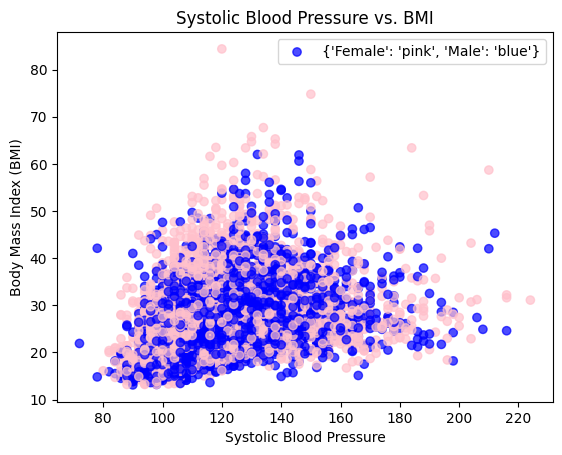

In [65]:
# Try to see if these two variables have any correlation USE ALPHA

gender_colors={'Female':'pink','Male':'blue'}
#the map function to associate the rows, with corresponding gender category, and color
colors=new_health_df['gender'].map(gender_colors)

plt.scatter(new_health_df['systolic_bp'],new_health_df['bmi'],c=colors,alpha=0.7, label=gender_colors)

plt.title('Systolic Blood Pressure vs. BMI')
plt.xlabel('Systolic Blood Pressure')
plt.ylabel('Body Mass Index (BMI)')

plt.legend()
plt.show()
#Is there a way I can put these side by side?

In [ ]:
#Pull out only male rows -> complete the t-test to find p value

In [ ]:
#Pull out only female rows -> complete the t-test to find p value

In [ ]:
#compare p values